In [1]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ClassGraphDat import GraphDataset
torch.manual_seed(42)

In [2]:
class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        # self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='target_to_source', root_weight=False)
        # self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='target_to_source', root_weight=False)
        # self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='target_to_source', root_weight=False)
        self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='source_to_target', root_weight=False)
        self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='source_to_target', root_weight=False)
        self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='source_to_target', root_weight=False)
        self.lin1 = nn.Linear(hidden_channels, int(hidden_channels/2))
        self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = F.dropout(F.relu(self.lin1(x)), p=0.2)
        x = self.lin2(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # x = self.sm(x)
        return x

In [3]:
# Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
def loss_function(reconstructed_x, original_x):
    # weights = torch.tensor([  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238], dtype=torch.float)
    total = 1.0#2204689.0
    # arr = [1410221,  794468] 
    arr = [1.0, 1.0]
    weights = torch.tensor([total/a for a in arr], dtype = torch.float)
    
    weights = weights/torch.sum(weights)
    # return F.cross_entropy(reconstructed_x, original_x, weight=weights, label_smoothing=0.2)
    # return F.cross_entropy(reconstructed_x, original_x, label_smoothing=0.4)
    return F.cross_entropy(reconstructed_x, original_x, weight=weights)
    # return F.cross_entropy(reconstructed_x, original_x)#/scale#, label_smoothing=0.4)   

In [239]:
def train(model, dat, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    # lossfunc = nn.CrossEntropyLoss()
    # print(data_loader)
    # printlosses = []
    # for dat in data_loader:
    optimizer.zero_grad()
    # pdb.set_trace()
    # print(np.shape(nodes), np.shape(edges), nodes, edges)
    n = dat[1] #torch.tensor(dat[1], dtype = torch.float) #nodes.squeeze_(0)
    e = dat[2] #torch.tensor(dat[2], dtype = torch.long) #edges.squeeze_(0)
    classes = dat[0] #torch.tensor(dat[2], dtype = torch.long)
    # class_now = get_class(meta, n)
    # print(np.shape(nodes), np.shape(edges), np.shape(class_now))
    try:
        if n.dim() == 1:
            n = n.unsqueeze(1)

        embed = model(n, e)

    except Exception as e:
        pdb.set_trace()

    # print(len(data[0][0]))
    # pdb.set_trace()
    # print(np.shape(class_now), class_now)
    # if np.mean(class_now.tolist()) < 0.01:
    #     pdb.set_trace()
    loss = loss_function(embed, classes) #cosine_loss(data[1][0].to(device), embed)
    loss = cosine_loss(embed, classes) 
    # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
    loss.backward()
    optimizer.step()
    total_loss += loss.detach().item()
    # printlosses.append(loss.detach().item())
    # if len(printlosses)%10000 == 0:
    #     printlosses = printlosses[-10000:]
    #     print(np.sum(printlosses)/10000.0)
    # embeddings.append(embed.detach())
    # print(total_loss)/10.0
    return total_loss / len(dat), embeddings, origs

In [240]:
folder_graph = './'
device = "cpu"
# fname = 'small_graphs.pth'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
files = ['alledges', 'allsucc', 'alltime', 'edgesList', 'nodeIDs']
hC = 10
inC = 40
outchannels = 2

In [241]:

fil2 = open('alltime.pickle', 'rb')
times = pickle.load(fil2)
fil2.close()

fil2 = open('allsucc.pickle', 'rb')
successes = pickle.load(fil2)
fil2.close()

fil2 = open('edgeList.pickle', 'rb')
edges = pickle.load(fil2)
fil2.close()

fil2 = open('nodeIDs.pickle', 'rb')
nodes = pickle.load(fil2)
fil2.close()

meanTimes = dict()
for n in times:
    meanTimes[n] = np.mean(times[n])

In [242]:
TIME_LIMIT =  400

# def round_function(x, d):
#     new = []
#     for r in x:
#         new.append(np.round(r,decimals=d))
#     # pdb.set_trace()
#     return tuple(new)

def get_class(a):
    if a > TIME_LIMIT:
        retVal = torch.tensor(0, dtype=torch.long)
        return retVal
    else:
        retVal = torch.tensor(1, dtype=torch.long)
        return retVal
    # arr = []
    # if a > TIME_LIMIT:
    #     arr.append(0)
    # else:
    #     arr.append(1)

    # try:
    #     retVal = torch.tensor(arr, dtype=torch.long)
    #     return retVal
    # except:
    #     pdb.set_trace()
    # edges

In [243]:
timeClasses = dict()
for n in meanTimes:
    timeClasses[n] = get_class(meanTimes[n])

times_ = []
for t in timeClasses.values():
    times_.append(t)


In [244]:

nodesList = []
for n in nodes:
    nodesList.append(n)

In [245]:


# dataset = GraphDataset(folder_graph, files)
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
dataloader = [torch.tensor(times_, dtype=torch.long).to(device), torch.tensor(nodesList, dtype=torch.float).to(device), torch.tensor(edges, dtype=torch.long).t().to(device)]
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.11)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
losses = []
embeds = []
acts = []


In [246]:
# dataloader[2]
np.shape(dataloader[2].t())

torch.Size([271885, 2])

In [247]:


for epoch in range(1, 30):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)
model.eval()
# Assuming encoder and decoder are your model's components
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, './Time_encoder_state_dict'+str(outchannels)+'.pth')
# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


Epoch 1, Loss: 0.2618
Epoch 2, Loss: 0.8942
Epoch 3, Loss: 0.3225
Epoch 4, Loss: 0.2492
Epoch 5, Loss: 0.2619
Epoch 6, Loss: 0.2230
Epoch 7, Loss: 0.2011
Epoch 8, Loss: 0.2095
Epoch 9, Loss: 0.2139
Epoch 10, Loss: 0.2033
Epoch 11, Loss: 0.1914
Epoch 12, Loss: 0.1886
Epoch 13, Loss: 0.1914
Epoch 14, Loss: 0.1876
Epoch 15, Loss: 0.1788
Epoch 16, Loss: 0.1756
Epoch 17, Loss: 0.1778
Epoch 18, Loss: 0.1774
Epoch 19, Loss: 0.1728
Epoch 20, Loss: 0.1696
Epoch 21, Loss: 0.1709
Epoch 22, Loss: 0.1718
Epoch 23, Loss: 0.1691
Epoch 24, Loss: 0.1664
Epoch 25, Loss: 0.1663
Epoch 26, Loss: 0.1670
Epoch 27, Loss: 0.1657
Epoch 28, Loss: 0.1634
Epoch 29, Loss: 0.1625


In [248]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 30):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './Time_encoder_state_dict'+str(outchannels)+'.pth')


Epoch 1, Loss: 0.1629
Epoch 2, Loss: 0.1620
Epoch 3, Loss: 0.1623
Epoch 4, Loss: 0.1615
Epoch 5, Loss: 0.1610
Epoch 6, Loss: 0.1613
Epoch 7, Loss: 0.1612
Epoch 8, Loss: 0.1608
Epoch 9, Loss: 0.1604
Epoch 10, Loss: 0.1603
Epoch 11, Loss: 0.1603
Epoch 12, Loss: 0.1601
Epoch 13, Loss: 0.1598
Epoch 14, Loss: 0.1596
Epoch 15, Loss: 0.1595
Epoch 16, Loss: 0.1594
Epoch 17, Loss: 0.1592
Epoch 18, Loss: 0.1590
Epoch 19, Loss: 0.1588
Epoch 20, Loss: 0.1587
Epoch 21, Loss: 0.1586
Epoch 22, Loss: 0.1584
Epoch 23, Loss: 0.1582
Epoch 24, Loss: 0.1580
Epoch 25, Loss: 0.1579
Epoch 26, Loss: 0.1578
Epoch 27, Loss: 0.1576
Epoch 28, Loss: 0.1574
Epoch 29, Loss: 0.1573


In [249]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(1, 30):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './Time_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.1571
Epoch 2, Loss: 0.1571
Epoch 3, Loss: 0.1571
Epoch 4, Loss: 0.1571
Epoch 5, Loss: 0.1570
Epoch 6, Loss: 0.1570
Epoch 7, Loss: 0.1570
Epoch 8, Loss: 0.1570
Epoch 9, Loss: 0.1570
Epoch 10, Loss: 0.1569
Epoch 11, Loss: 0.1569
Epoch 12, Loss: 0.1569
Epoch 13, Loss: 0.1569
Epoch 14, Loss: 0.1568
Epoch 15, Loss: 0.1568
Epoch 16, Loss: 0.1568
Epoch 17, Loss: 0.1568
Epoch 18, Loss: 0.1567
Epoch 19, Loss: 0.1567
Epoch 20, Loss: 0.1567
Epoch 21, Loss: 0.1567
Epoch 22, Loss: 0.1567
Epoch 23, Loss: 0.1566
Epoch 24, Loss: 0.1566
Epoch 25, Loss: 0.1566
Epoch 26, Loss: 0.1566
Epoch 27, Loss: 0.1565
Epoch 28, Loss: 0.1565
Epoch 29, Loss: 0.1565


In [250]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(1, 30):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './Time_encoder_state_dict'+str(outchannels)+'.pth')

Epoch 1, Loss: 0.1565
Epoch 2, Loss: 0.1565
Epoch 3, Loss: 0.1565
Epoch 4, Loss: 0.1565
Epoch 5, Loss: 0.1565
Epoch 6, Loss: 0.1565
Epoch 7, Loss: 0.1565
Epoch 8, Loss: 0.1564
Epoch 9, Loss: 0.1564
Epoch 10, Loss: 0.1564
Epoch 11, Loss: 0.1564
Epoch 12, Loss: 0.1564
Epoch 13, Loss: 0.1564
Epoch 14, Loss: 0.1564
Epoch 15, Loss: 0.1564
Epoch 16, Loss: 0.1564
Epoch 17, Loss: 0.1564
Epoch 18, Loss: 0.1564
Epoch 19, Loss: 0.1564
Epoch 20, Loss: 0.1564
Epoch 21, Loss: 0.1564
Epoch 22, Loss: 0.1564
Epoch 23, Loss: 0.1564
Epoch 24, Loss: 0.1564
Epoch 25, Loss: 0.1564
Epoch 26, Loss: 0.1564
Epoch 27, Loss: 0.1564
Epoch 28, Loss: 0.1564
Epoch 29, Loss: 0.1564


In [251]:
# GAE = GraphEncoderWithResidual(inC, hC, outchannels)
# import pickle
import numpy as np
import torch


from collections import defaultdict 

encoder_dict = torch.load('./Time_encoder_state_dict2.pth')


In [252]:

GAE = GraphEncoderWithResidual(inC, hC, outchannels)
GAE.load_state_dict(encoder_dict)
emb = []
# arrtosave = []

In [253]:
print(np.shape(torch.tensor([nodesList[0]], dtype=torch.float)), np.shape(torch.tensor([[],[]], dtype=torch.long)))
# GAE(torch.tensor([nodesList[0]], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long))


torch.Size([1, 40]) torch.Size([2, 0])


In [254]:

# for i in arr1: 
GAE.eval()
emb = []
for ii in nodesList: 
    # break
# GAE(torch.tensor([ast.literal_eval(i)], dtype=torch.float), torch.empty((2,0), dtype=torch.int64).detach().tolist()[0])
    try:
        # pdb.set_trace()
        emb.append(GAE(torch.tensor([ii], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long)).detach().tolist()[0])
        # arrtosave.append(i) 
    except Exception as e:
        print(e)
        print(np.shape(ii))

In [255]:
times_
times_check = []
for t in times_:
    times_check.append(t.tolist())

In [256]:
# import numpy as np
# from scipy.special import expit, logit
# emb
# newembs = []
# for e in emb:
#     newembs.append(expit(e))

# newembs
# emb

In [257]:
print(np.shape(times_check), np.shape(emb))

y_true_indices = times_check#np.argmax(times_check, axis=1)
y_pred_indices = np.argmax(emb, axis=1)
# print(np.argmax(emb, axis=1)[0:10])
# print(np.argmax(arrclass, axis=1)[0:10])


(88568,) (88568, 2)


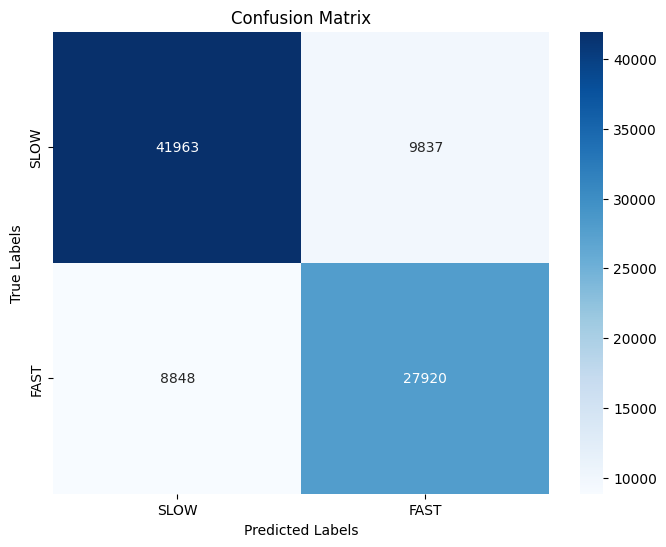

In [258]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(y_true_indices, y_pred_indices)
# ConfusionMatrixDisplay(cm).plot()
# CLIST =  ["Fast/Failure", "Slow/Failure", "Fast/Success", "Slow/Success"]

CLIST =  ["SLOW", "FAST"]
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# 

In [259]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

In [260]:
print('roc auc score: ', roc_auc_score(y_true_indices, y_pred_indices))
print('precision score: ', precision_score(y_true_indices, y_pred_indices))
print('recall score: ', recall_score(y_true_indices, y_pred_indices))
print('f1 score: ', f1_score(y_true_indices, y_pred_indices))
print('accuracy score: ', accuracy_score(y_true_indices, y_pred_indices))


roc auc score:  0.7847262434011781
precision score:  0.7394655295706757
recall score:  0.7593559617058312
f1 score:  0.7492787655149278
accuracy score:  0.7890321560834613


10:

roc auc score:  0.7847262434011781
precision score:  0.7394655295706757
recall score:  0.7593559617058312
f1 score:  0.7492787655149278
accuracy score:  0.7890321560834613

5: 

roc auc score:  0.7807121435124047
precision score:  0.7352067868504772
recall score:  0.7542428198433421
f1 score:  0.7446031575555795
accuracy score:  0.7852045885647186

In [261]:


# print(np.sum([1 for y in y_true_indices if y == 1]))
# total = np.sum(cm, axis=1)
# print(total, np.sum(total))
# print(cm)
# 0: 14022, 1: 35079, 2: 780448 1375238

In [7]:
# import torch
# import statistics
# arr = []
# for a in meta:
#     arr.append(statistics.mean(meta[a]))

# times_ = []
# for t in timeClasses.values():
#     times_.append(t)
# # print(n)
# import matplotlib.pyplot as plt
# x=plt.hist(times_)
# plt.xlim([0,200])


# import shutil
# import os
# import numpy as np
# import pandas as pd
# from ast import literal_eval
# from collections import defaultdict
# def other():
#     folder = '../../graphsage_results/CDC/multiple_agent_env_results/'
#     files = os.listdir(folder)
#     files = [file for file in files if file.endswith('.csv') and file.startswith('1')]
#     files = np.sort(files)
#     # data_files = []
#     metadata_file = folder + 'metadata.csv'
#     # folder_graph = './graphs/RS/fast_multiple_graphs/'
#     # new_metadata_file = folder_graph + 'metadata.csv'
#     # graph_metaFile = 'graphMetadata.csv'
#     # meta_arr = []
#     metadata = pd.read_csv(metadata_file) 
#     metadata.site_qualities=metadata.site_qualities.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(lambda x: tuple([tuple(a) for a in x]))
#     metadata.site_qualities=metadata.site_qualities.apply(lambda x: tuple(x))
#     df = metadata.groupby(by=['site_qualities', 'site_positions', 'num_agents'], as_index=False).agg(lambda x: x.tolist())
#     Gtime = defaultdict(list)
#     Gsucc = defaultdict(list)
#     Gedge = defaultdict(defaultdict)
    
#     for some_id, entry in enumerate(df.iterrows()):
#         # copy files
#         for file in entry[1].iloc[3]:
#             shutil.copyfile(folder+file, '../../oneGraphFiles/'+file)
#         break

other()

In [1]:
import os 
import shutil
fold = 'finished_some_train/'
fold_new = 'singleGraph/'
files = os.listdir(fold)
for file in files[:-1]:
    if file.startswith('(0.045, 0.977'):
        print(file)
        shutil.copy(fold+file, fold_new+file)

(0.045, 0.977, 0.16, 0.439)((100.0, 0.0), (0.0, 100.0), (-100.0, 0.0), (-0.0, -100.0))5_1710456709365868.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((150.0, 0.0), (0.0, 150.0), (-150.0, 0.0), (-0.0, -150.0))5_1710456709399932.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((200.0, 0.0), (0.0, 200.0), (-200.0, 0.0), (-0.0, -200.0))5_1710456709396414.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((200.0, 0.0), (0.0, 200.0), (-200.0, 0.0), (-0.0, -200.0))5_1710456709394919.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((150.0, 0.0), (0.0, 150.0), (-150.0, 0.0), (-0.0, -150.0))5_1710456709398955.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((100.0, 0.0), (0.0, 100.0), (-100.0, 0.0), (-0.0, -100.0))5_1710456709368549.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((200.0, 0.0), (0.0, 200.0), (-200.0, 0.0), (-0.0, -200.0))5_1710456709395495.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((150.0

In [1]:
import os 
import shutil
import numpy as np
fold = '../final_experiments/allGraphs_train/'
fold_new = '../final_experiments/allGraphs_test/'
files = os.listdir(fold)
for file in files[:-1]:
    if np.random.random() > 0.7:
        print(file)
        shutil.move(fold+file, fold_new+file)

(0.774, 0.072)((150.0, 0.0), (-150.0, 0.0))10_1710456704732901.csv_noAgentPos_single_sim.pickle
(0.064, 0.479, 0.983)((100.0, 0.0), (-50.0, 86.603), (-50.0, -86.603))5_1710456707368491.csv_noAgentPos_single_sim.pickle
(0.77, 0.197)((150.0, 0.0), (-150.0, 0.0))10_1710456705011860.csv_noAgentPos_single_sim.pickle
(0.774, 0.072)((100.0, 0.0), (-100.0, 0.0))10_1710456704708811.csv_noAgentPos_single_sim.pickle
(0.356, 0.939)((100.0, 0.0), (-100.0, 0.0))10_1710456704781637.csv_noAgentPos_single_sim.pickle
(0.77, 0.197)((100.0, 0.0), (-100.0, 0.0))10_1710456704988819.csv_noAgentPos_single_sim.pickle
(0.356, 0.939)((100.0, 0.0), (-100.0, 0.0))10_1710456704775056.csv_noAgentPos_single_sim.pickle
(0.045, 0.977, 0.16, 0.439)((200.0, 0.0), (0.0, 200.0), (-200.0, 0.0), (-0.0, -200.0))5_1710456709396414.csv_noAgentPos_single_sim.pickle
(0.399, 0.133, 0.933, 0.249)((200.0, 0.0), (0.0, 200.0), (-200.0, 0.0), (-0.0, -200.0))5_1710456709345391.csv_noAgentPos_single_sim.pickle
(0.951, 0.108, 0.362)((150.